In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load in the dataset and print out the shape and column names
df = pd.read_csv("paddydataset.csv")
print(df.shape)
print(df.columns.tolist())

(2789, 45)
['Hectares ', 'Agriblock', 'Variety', 'Soil Types', 'Seedrate(in Kg)', 'LP_Mainfield(in Tonnes)', 'Nursery', 'Nursery area (Cents)', 'LP_nurseryarea(in Tonnes)', 'DAP_20days', 'Weed28D_thiobencarb', 'Urea_40Days', 'Potassh_50Days', 'Micronutrients_70Days', 'Pest_60Day(in ml)', '30DRain( in mm)', '30DAI(in mm)', '30_50DRain( in mm)', '30_50DAI(in mm)', '51_70DRain(in mm)', '51_70AI(in mm)', '71_105DRain(in mm)', '71_105DAI(in mm)', 'Min temp_D1_D30', 'Max temp_D1_D30', 'Min temp_D31_D60', 'Max temp_D31_D60', 'Min temp_D61_D90', 'Max temp_D61_D90', 'Min temp_D91_D120', 'Max temp_D91_D120', 'Inst Wind Speed_D1_D30(in Knots)', 'Inst Wind Speed_D31_D60(in Knots)', 'Inst Wind Speed_D61_D90(in Knots)', 'Inst Wind Speed_D91_D120(in Knots)', 'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 'Wind Direction_D61_D90', 'Wind Direction_D91_D120', 'Relative Humidity_D1_D30', 'Relative Humidity_D31_D60', 'Relative Humidity_D61_D90', 'Relative Humidity_D91_D120', 'Trash(in bundles)', 'Padd

In [3]:
# Mean yield by variety
variety_means = df.groupby("Variety")["Paddy yield(in Kg)"].agg(["mean", "std", "count"]).round(2)
print(variety_means)

                 mean      std  count
Variety                              
CO_43        22540.66  9191.89    732
delux ponni  22614.45  9355.52    996
ponmani      22411.11  9064.04   1061


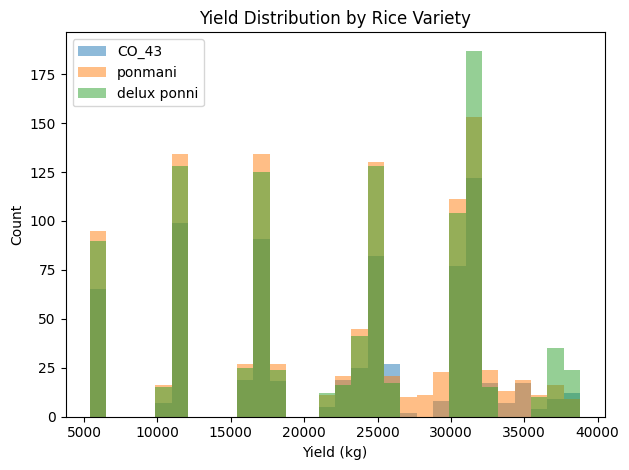

In [8]:
# Creating plot to visualize yield distribution by variety
varieties = df["Variety"].unique()

for v in varieties:
    subset = df[df["Variety"] == v]["Paddy yield(in Kg)"]
    plt.hist(subset, bins=30, alpha=0.5, label=v)

plt.xlabel("Yield (kg)")
plt.ylabel("Count")
plt.title("Yield Distribution by Rice Variety")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
np.random.seed(42)
n_boot = 10000
boot_results = {}
#  Bootstrap CIs for each variety mean
for variety in df["Variety"].unique():
    group = df[df["Variety"] == variety]["Paddy yield(in Kg)"].values
    boot_means = [np.mean(np.random.choice(group, size=len(group), replace=True)) for _ in range(n_boot)]
    boot_results[variety] = {
        "mean": round(np.mean(group), 2),
        "ci": (round(np.percentile(boot_means, 2.5), 2), round(np.percentile(boot_means, 97.5), 2))
    }

for v, res in boot_results.items():
    print(f"{v}: mean = {res['mean']}, 95% CI = {res['ci']}")

CO_43: mean = 22540.66, 95% CI = (np.float64(21876.46), np.float64(23202.34))
ponmani: mean = 22411.11, 95% CI = (np.float64(21866.24), np.float64(22951.73))
delux ponni: mean = 22614.45, 95% CI = (np.float64(22017.24), np.float64(23187.17))


In [10]:
# Bootstrap CI for the difference between best and worst variety
best = max(boot_results, key=lambda v: boot_results[v]["mean"])
worst = min(boot_results, key=lambda v: boot_results[v]["mean"])

group_best = df[df["Variety"] == best]["Paddy yield(in Kg)"].values
group_worst = df[df["Variety"] == worst]["Paddy yield(in Kg)"].values

boot_diffs = [
    np.mean(np.random.choice(group_best, size=len(group_best), replace=True)) -
    np.mean(np.random.choice(group_worst, size=len(group_worst), replace=True))
    for _ in range(n_boot)
]

print(f"{best} vs {worst}")
print(f"Observed difference: {np.mean(group_best) - np.mean(group_worst):.2f} kg")
print(f"95% CI: ({np.percentile(boot_diffs, 2.5):.2f}, {np.percentile(boot_diffs, 97.5):.2f})")

delux ponni vs ponmani
Observed difference: 203.34 kg
95% CI: (-597.11, 1000.96)
